In [3]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

In [4]:
import pandas as pd
import numpy as np
from tensorflow.keras import utils # utils.to_categorical()
from tensorflow.keras.models import Sequential #모델생성
from tensorflow.keras.layers import Dense,Input 
import matplotlib.pyplot as plt

# 로지스틱회귀분석(이진분류)
## 1. 데이터 셋 생성 및 전처리

In [5]:
# 1. csv파일을 데이터 프래임으로 읽어오기(결측치처리,균형확인 용이)=>넘파이 배열로 변환 =>데이터 분할

df = pd.read_csv('data/pima-indians-diabetes.csv',comment='#',header=None)
# 1. 임신횟수
# 2. 2시간내 포도당 농도
# 3. 혈압
# 4. 피부접힘 두께
# 5. 인슐린수치
# 6. BMI체질량지수
# 7. 가족력
# 8. 나이
# 9. 당뇨병발병여부
df.sample()

,0,1,2,3,4,5,6,7,8
92,7,81,78,40,48,46.7,0.261,42,0


In [6]:
df.shape

(768, 9)

In [7]:
df.info()#결측치없음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.isna().sum() # 열별 결측치 갯수

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64

In [9]:
# 타겟변수의 균형 확인
df[8].value_counts()/len(df)

0    0.651042
1    0.348958
Name: 8, dtype: float64

In [10]:
# np.array(df)
dataset = df.values
dataset = df.to_numpy()

In [11]:
# 2. csv파일을 넘파이 배열 읽어오기 =>데이터 분할
    # np.loadtxt()
dataset = np.loadtxt('data/pima-indians-diabetes.csv',
                     encoding='utf-8',
                     delimiter=',',
                     # comments='#'
                     )
dataset.shape

(768, 9)

In [12]:
# 데이터 분할 : 학습데이터셋(모델학습용) + 시험데이터셋*(모델평가용)
X_train = dataset[:620,:-1]
y_train = dataset[:620,-1]
X_test  = dataset[620:,:-1]
y_test  = dataset[620:,-1]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((620, 8), (620,), (148, 8), (148,))

## 2. 모델구성

In [13]:
model = Sequential()
# model = add(Dense(64,
#                  input_dim=8, input_shpae=(8,),
#                  activation='relu'))

model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=64, activation='elu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid')) #이전분류(로지스틱회귀분석)의 출력층 활성화함수
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                288       
                                                                 
 dense_1 (Dense)             (None, 64)                2112      
                                                                 
 dense_2 (Dense)             (None, 16)                1040      
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 3,457
Trainable params: 3,457
Non-trainable params: 0
_________________________________________________________________


## 3. 학습과정 설정

In [14]:
# model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['binary_accuracy'])
# accuracy가 자동적으로 binary_accuracy 적용
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

## 4. 학습

In [15]:
%%time
hist = model.fit(X_train, y_train, #훈련(학습)데이터 셋
                 epochs = 200,
                 batch_size=310,
#                  validation_data=(X_val,y_val)
                 validation_split=0.1, # 검증데이터비율(훈련데이터셋에서 10%는 검증데이터 셋으로)
                 verbose=0) # 학습과정 로그 출력 안 함

CPU times: total: 11.6 s
Wall time: 10.1 s


## 5.모델평가하기
- 학습과정 시각화하여 살펴보기
- 평가(시험데이터셋)
- 교차표(혼돈매트릭스, 성능평가지표)그리기

In [17]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

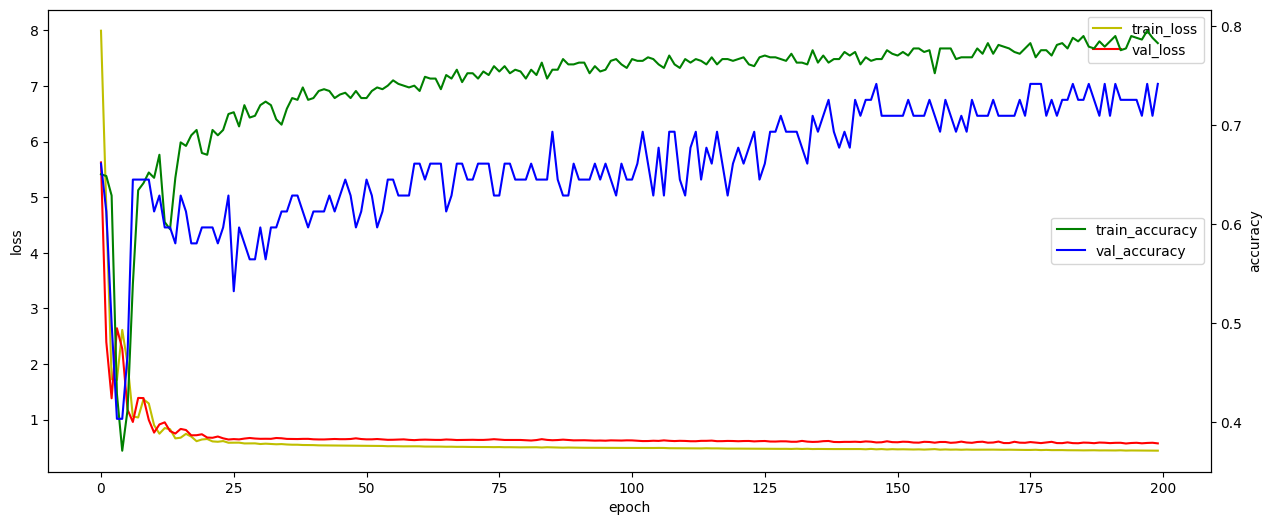

In [18]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')

plt.show()

In [19]:
# 모델 평가(x)
model.evaluate(X_train,y_train, batch_size=310)

2/2 [==============================] - 0s 5ms/step - loss: 0.4535 - accuracy: 0.7839


[0.4535489082336426, 0.7838709950447083]

In [20]:
# 모델 평가(o)
loss,accuracy = model.evaluate(X_test, y_test)
print(f'정확도:{accuracy*100:.2f}%')

5/5 [==============================] - 0s 3ms/step - loss: 0.6108 - accuracy: 0.6824
정확도:68.24%


In [21]:
# 교차표(혼동행렬, 성능평가지표)
y_hat = (model.predict(X_test)>0.5).astype(int)
# y_test : 1차원
# y_hat : 2차원

5/5 [==============================] - 0s 2ms/step


In [22]:
TN=0; FP=0; FN=0; TP=0
for y, h in zip(y_test, y_hat.reshape(-1)):
#     print(y,h)
    if y==0 and h==0:
        TN +=1
    elif y==0 and h==1:
        FP +=1
    elif y==1 and h==0:
        FN +=1
    else:
        TP +=1
print(TN,FP)
print(FN,TP)

78 18
29 23


In [20]:
y_test.shape

(148,)

In [21]:
ctab = pd.crosstab(y_test, # 실제값
           y_hat.reshape(-1))
ctab.index.name = '실제값'
ctab.columns.name = '예측값'
pd.crosstab(y_test.astype(int),
           y_hat.reshape(-1),
           rownames=['실제값'],
           colnames=['예측값'])

예측값,0,1
실제값,,
0,76,20
1,28,24


In [22]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat) # 결과가 numpy

array([[76, 20],
       [28, 24]], dtype=int64)

In [23]:
precision = 26/(15+26)
recall = 26/(26+26)
print('recall:', recall)
print('precision:', precision)

recall: 0.5
precision: 0.6341463414634146


## 6. 모델사용(예측,저장)

In [24]:
# 모델저장
from tensorflow.keras.models import save_model, load_model
# model.save('model/05_pima.h5')
save_model(model,'model/05_pima.h5')

In [25]:
model2 = load_model('model/05_pima.h5')

In [26]:
X_test[0]

array([  2.   , 112.   ,  86.   ,  42.   , 160.   ,  38.4  ,   0.246,
        28.   ])

In [27]:
#예측하기
(model.predict([[6,148,72,35,0,33.6,0.627,50],
               [3,78,50,32,88,31,0.248,26]
               ])>0.5).astype(int)

1/1 [==============================] - 0s 76ms/step


array([[1],
       [0]])

# 분류분석
- 1. 데이터 생성 및 전처리 : 훈련셋600, 검증셋100, 테스트셋68로 분리. 타겟 변수의 원핫인코딩
- 2. 모델 생성(input8,output2) - 출력층의 활성화함수 softmax
- 3. 모델학습과정 loss='categorical_crossentropy' metrics=['accuracy']
- 4. 모델학습 validation_data = (X_val, y_val)
- 5. 모델학습평가
- 6. 모델사용
    model.predict(input_data).argmax()
    
## 1. 데이터셋 생성 및 전처리     

In [61]:
df = pd.read_csv('data/pima-indians-diabetes.csv',comment='#',header=None)
dataset = df.values

In [62]:
# 훈련셋600, 검증셋100, 테스트셋68
X_train = dataset[:600,:-1]
y_train = dataset[:600,-1]

X_val   = dataset[600:700,:-1]
y_val   = dataset[600:700,-1]

X_test  = dataset[700:,:-1]
y_test  = dataset[700:,-1]

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((600, 8), (600,), (100, 8), (100,), (68, 8), (68,))

In [63]:
# 원핫인코딩(0 :1 0 / 1: 0 1)
Y_train = utils.to_categorical(y_train, num_classes=2)# pd.get_dummies(y_train).values
Y_val   = utils.to_categorical(y_val,2)
Y_test  = utils.to_categorical(y_test)
X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape

((600, 8), (600, 2), (100, 8), (100, 2), (68, 8), (68, 2))

In [64]:
print('원데이터 :', y_train[:3])
print('원핫인코딩 데이터 :\n', Y_train[:3])

원데이터 : [1. 0. 1.]
원핫인코딩 데이터 :
 [[0. 1.]
 [1. 0.]
 [0. 1.]]


## 2. 모델생성(input8->target2)

In [65]:
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=64, activation='elu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid')) #분류분석의 출력층 활성화 함수
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 32)                288       
                                                                 
 dense_17 (Dense)            (None, 64)                2112      
                                                                 
 dense_18 (Dense)            (None, 16)                1040      
                                                                 
 dense_19 (Dense)            (None, 1)                 17        
                                                                 
Total params: 3,457
Trainable params: 3,457
Non-trainable params: 0
_________________________________________________________________


## 3. 학습과정 설정

In [66]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

## 4. 모델학습

In [2]:
# hist = model.fit(X_train, y_train,
#                  epochs = 200,
#                  batch_size=310,
#                  validation_split=0.1, 
#                  validation_data=(X_val, y_val),
#                  verbose=0) 

hist = model.fit(X_train, Y_train,
                epochs=200,
                validation_data=(X_val, Y_val),
                verbose=1)

NameError: name 'model' is not defined

## 5. 모델평가하기

In [1]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')

plt.show()

NameError: name 'plt' is not defined

In [47]:
# 모델평가
loss,accuracy = model.evaluate(X_test,y_test)
print('loss:',loss)
print('accuracy:',accuracy)

3/3 [==============================] - 0s 4ms/step - loss: 0.5858 - accuracy: 0.6912
loss: 0.5858463048934937
accuracy: 0.6911764740943909


In [48]:
# 혼동행렬==교차표
y_hat = (model.predict(X_test)>0.5).astype(int).reshape(-1)
y_hat.shape, y_test.shape

3/3 [==============================] - 0s 2ms/step


((68,), (68,))

In [49]:
#교차표
pd.crosstab(y_test, y_hat, rownames=['실제값'],colnames=['예측값'])

예측값,0,1
실제값,,
0.0,39,2
1.0,19,8


In [68]:
# 혼동행렬(numpy 배열)
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)

array([[39,  2],
       [19,  8]], dtype=int64)

## 6.모델사용(예측)

In [69]:
X_test[0]

array([  2.   , 122.   ,  76.   ,  27.   , 200.   ,  35.9  ,   0.483,
        26.   ])

In [70]:
model.predict([[2,122,76,27,200,35.9,0.483,26]]).argmax(axis=1)

1/1 [==============================] - 0s 127ms/step


array([0], dtype=int64)